# Quoridor ML Training Pipeline

Minimal ML workflow: Data → EDA → Preprocessing → Training → Evaluation → Best Model

## 1. Imports & Setup

In [29]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
print('✓ Imports OK')

✓ Imports OK


## 2. Load Data

In [30]:
HF_DATASET = "BILALfym/quoridor_dataset"
# LOCAL_CSV = Path("ml_moves_dataset.csv")  # Alternative : générer via python -m quoridor.ML.extract_moves_dataset

try:
    from datasets import load_dataset
    print(f"Chargement depuis HuggingFace : {HF_DATASET}")
    ds = load_dataset(HF_DATASET, split="train")
    df = ds.to_pandas()
    
except ModuleNotFoundError:
    print("ERREUR : le module 'datasets' n'est pas installe.")
    print("  → Lance : pip install -r requirements.txt")
    print("  → Ou genere le dataset localement : python -m quoridor.ML.extract_moves_dataset")
    print("    puis remplace le chargement HuggingFace par : df = pd.read_csv('ml_moves_dataset.csv')")
    raise
except Exception as e:
    print(f"ERREUR lors du chargement HuggingFace : {e}")
    print("  → Lance : pip install -r requirements.txt")
    print("  → Ou genere le dataset localement : python -m quoridor.ML.extract_moves_dataset")
    print("    puis remplace le chargement HuggingFace par : df = pd.read_csv('ml_moves_dataset.csv')")
    raise

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

Chargement depuis HuggingFace : BILALfym/quoridor_dataset
Shape: (34365, 23)

Columns: ['game_id', 'turn', 'game_phase', 'my_dist_before', 'opp_dist_before', 'dist_advantage_before', 'my_walls_before', 'opp_walls_before', 'wall_advantage_before', 'my_row_before', 'my_col_before', 'opp_row_before', 'opp_col_before', 'my_center_distance_before', 'opp_center_distance_before', 'is_pawn_move', 'is_wall_move', 'wall_is_horizontal', 'wall_is_vertical', 'pawn_move_distance', 'my_progress', 'opp_slowdown', 'label']

Label distribution:
label
 1    17332
-1    17033
Name: count, dtype: int64

Missing values:
game_id                       0
turn                          0
game_phase                    0
my_dist_before                0
opp_dist_before               0
dist_advantage_before         0
my_walls_before               0
opp_walls_before              0
wall_advantage_before         0
my_row_before                 0
my_col_before                 0
opp_row_before                0
opp_col_be

## 3. EDA

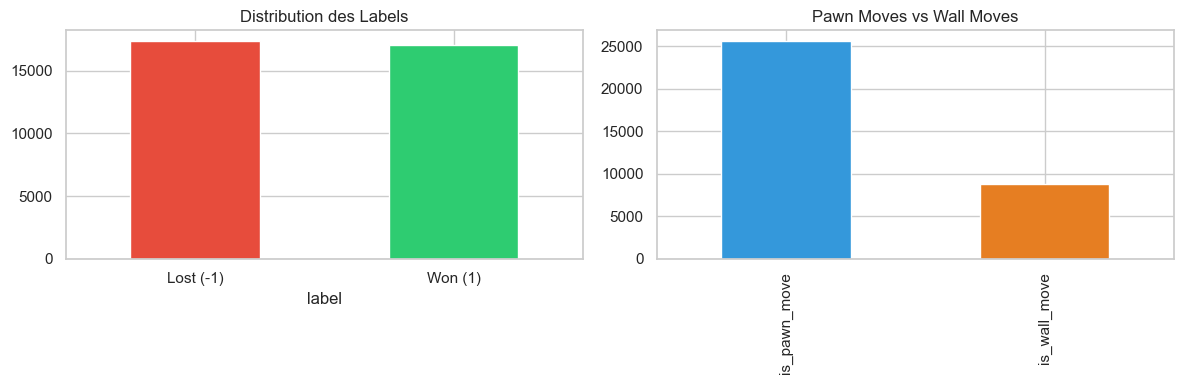

Dataset: 34365 moves from 499 games
Avg turns per game: 68.9


In [31]:
# Distribution des labels (barplot)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution des Labels')
axes[0].set_xticklabels(['Lost (-1)', 'Won (1)'], rotation=0)

# Ratio move types
move_types = df[['is_pawn_move', 'is_wall_move']].sum()
move_types.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22'])
axes[1].set_title('Pawn Moves vs Wall Moves')
plt.tight_layout()
plt.show()

print(f'Dataset: {len(df)} moves from {df["game_id"].nunique()} games')
print(f'Avg turns per game: {df.groupby("game_id")["turn"].max().mean():.1f}')


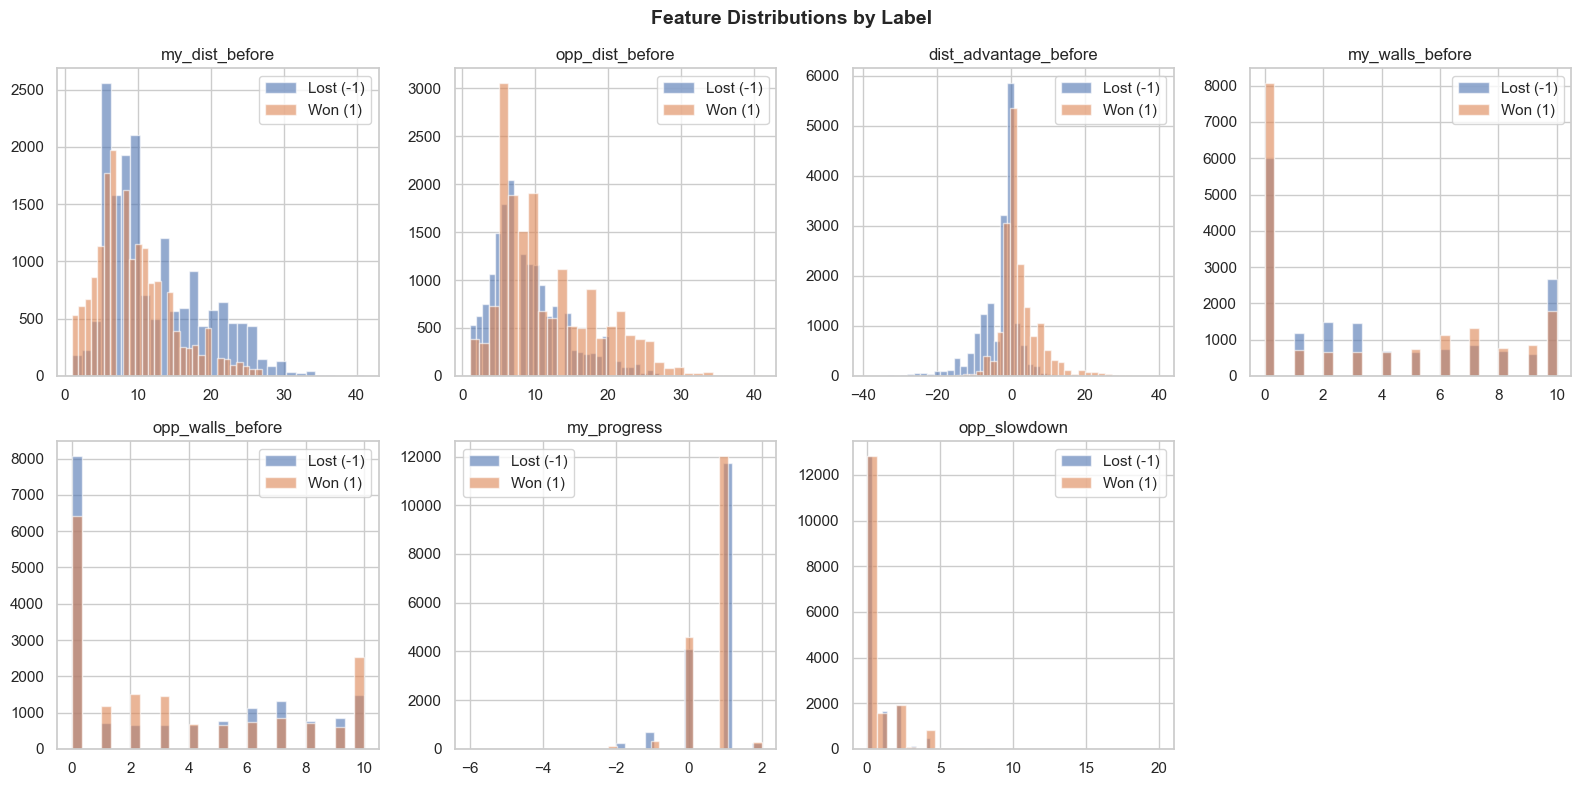

In [32]:
# Histogrammes des features numeriques principales
num_features = ['my_dist_before', 'opp_dist_before', 'dist_advantage_before',
                'my_walls_before', 'opp_walls_before', 'my_progress', 'opp_slowdown']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    df.groupby('label')[col].hist(ax=axes[i], alpha=0.6, bins=30, legend=True)
    axes[i].set_title(col)
    axes[i].legend(['Lost (-1)', 'Won (1)'])
axes[-1].axis('off')
plt.suptitle('Feature Distributions by Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


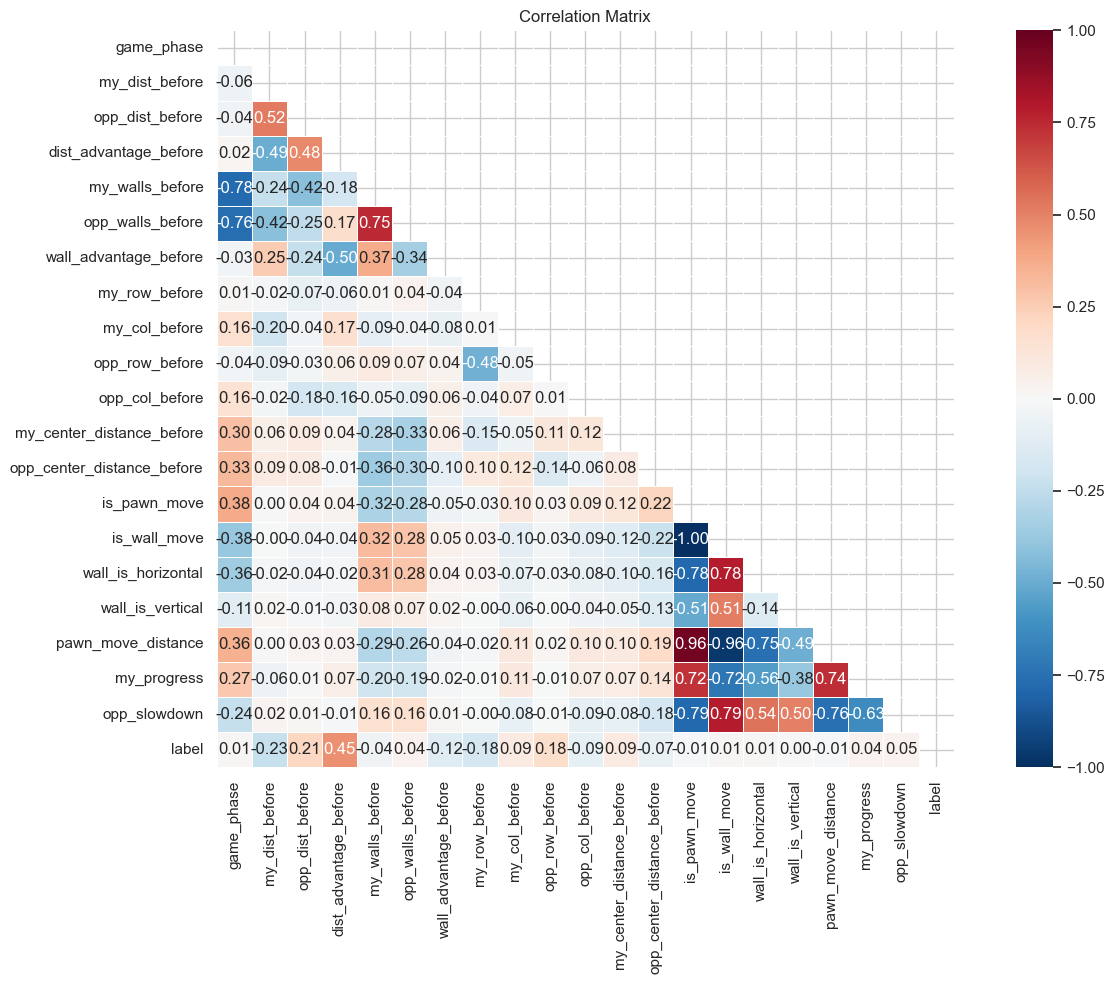

Top features correlated with label:
dist_advantage_before         0.453294
my_dist_before                0.231134
opp_dist_before               0.212151
my_row_before                 0.177964
opp_row_before                0.176577
wall_advantage_before         0.123013
opp_col_before                0.089908
my_col_before                 0.088229
my_center_distance_before     0.086196
opp_center_distance_before    0.074285
opp_slowdown                  0.045793
my_walls_before               0.044568
opp_walls_before              0.042565
my_progress                   0.042285
wall_is_horizontal            0.012977
is_wall_move                  0.012907
is_pawn_move                  0.012907
game_phase                    0.010086
pawn_move_distance            0.009564
wall_is_vertical              0.002601


In [33]:
# Matrice de correlation
feature_cols_eda = [c for c in df.columns if c not in ['game_id', 'turn']]
corr = df[feature_cols_eda].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('Top features correlated with label:')
print(label_corr.to_string())


## 4. Preprocessing

In [35]:
# Remove non-feature columns
EXCLUDE = ['game_id', 'turn', 'label']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'X shape: {df[feature_cols].shape}')

X = df[feature_cols].copy()
y = df['label'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape}')
print(f'Test: {X_test.shape}')
print(f'\nTrain label balance: {y_train.value_counts().to_dict()}')
print(f'Test label balance: {y_test.value_counts().to_dict()}')

Features (20): ['game_phase', 'my_dist_before', 'opp_dist_before', 'dist_advantage_before', 'my_walls_before', 'opp_walls_before', 'wall_advantage_before', 'my_row_before', 'my_col_before', 'opp_row_before', 'opp_col_before', 'my_center_distance_before', 'opp_center_distance_before', 'is_pawn_move', 'is_wall_move', 'wall_is_horizontal', 'wall_is_vertical', 'pawn_move_distance', 'my_progress', 'opp_slowdown']
X shape: (34365, 20)

Train: (27492, 20)
Test: (6873, 20)

Train label balance: {1: 13866, -1: 13626}
Test label balance: {1: 3466, -1: 3407}


## 5. Model Training & Evaluation

In [5]:
# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    print(f'\n{name}...')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluate
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # AUC (convert labels to binary: -1→0, 1→1)
    y_test_binary = (y_test == 1).astype(int)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred_test
    auc = roc_auc_score(y_test_binary, y_pred_proba) if hasattr(model, 'predict_proba') else 0.5
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1': f1,
        'auc': auc,
    }
    
    print(f'  Train Acc: {train_acc:.4f}')
    print(f'  Test Acc:  {test_acc:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  AUC:       {auc:.4f}')

print('\n✓ Training complete')


LogisticRegression...
  Train Acc: 0.7572
  Test Acc:  0.7550
  F1 Score:  0.7587
  AUC:       0.8333

DecisionTree...
  Train Acc: 0.8400
  Test Acc:  0.8359
  F1 Score:  0.8418
  AUC:       0.9306

RandomForest...
  Train Acc: 1.0000
  Test Acc:  0.9383
  F1 Score:  0.9389
  AUC:       0.9866

GradientBoosting...
  Train Acc: 0.8685
  Test Acc:  0.8661
  F1 Score:  0.8679
  AUC:       0.9540

✓ Training complete


## 6. Compare & Select Best Model

In [6]:
# Results summary
summary = pd.DataFrame([
    {
        'Model': name,
        'Train Acc': r['train_acc'],
        'Test Acc': r['test_acc'],
        'F1': r['f1'],
        'AUC': r['auc'],
    }
    for name, r in results.items()
])

print('\n=== Model Comparison ===')
print(summary.to_string(index=False))

# Best by AUC
best_name = summary.loc[summary['AUC'].idxmax(), 'Model']
best_model = results[best_name]['model']

print(f'\n✓ BEST MODEL: {best_name}')
print(f'  Test Accuracy: {results[best_name]["test_acc"]:.4f}')
print(f'  AUC: {results[best_name]["auc"]:.4f}')


=== Model Comparison ===
             Model  Train Acc  Test Acc       F1      AUC
LogisticRegression   0.757238  0.754983 0.758739 0.833333
      DecisionTree   0.839953  0.835880 0.841795 0.930611
      RandomForest   0.999964  0.938309 0.938887 0.986639
  GradientBoosting   0.868544  0.866143 0.867854 0.954010

✓ BEST MODEL: RandomForest
  Test Accuracy: 0.9383
  AUC: 0.9866


## 7. Best Model Details

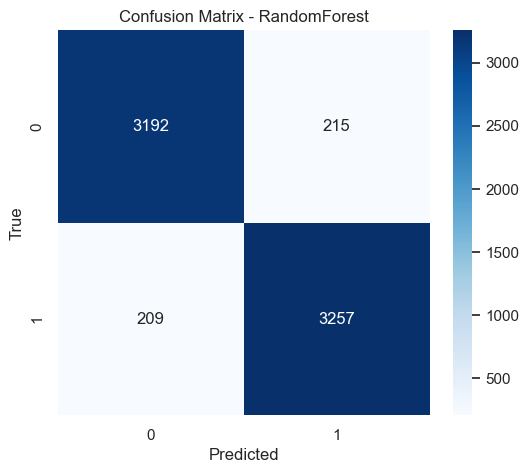


RandomForest - Classification Report:
              precision    recall  f1-score   support

   Lost (-1)       0.94      0.94      0.94      3407
     Won (1)       0.94      0.94      0.94      3466

    accuracy                           0.94      6873
   macro avg       0.94      0.94      0.94      6873
weighted avg       0.94      0.94      0.94      6873



In [7]:
# Confusion matrix
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Classification report
print(f'\n{best_name} - Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Lost (-1)', 'Won (1)']))

## 8. Neural Network (Keras)

Second model: a dense MLP trained with Keras to compare against RandomForest.

In [12]:
%pip install tensorflow


  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (7.4 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-macosx_10_9_universal2.whl.metadata (8.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (34 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 13.7 MB/s  0:00:16m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
print(f'TensorFlow {tf.__version__} — GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.21.0 — GPU: []


### 8.1 Data Preparation for Neural Network

In [21]:
# StandardScaler (obligatoire pour les reseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversion labels : -1 -> 0, 1 -> 1 (pour binary_crossentropy)
y_train_nn = ((y_train + 1) / 2).astype(int)
y_test_nn = ((y_test + 1) / 2).astype(int)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'y_train_nn distribution: {np.bincount(y_train_nn)}')

X_train_scaled shape: (27492, 20)
y_train_nn distribution: [13626 13866]


### 8.2 Model Architecture

In [22]:
def build_model(input_dim=20):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model

nn_model = build_model(X_train_scaled.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

### 8.3 Training with Early Stopping

In [23]:
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=15, restore_best_weights=True, mode='max'
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

history = nn_model.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6980 - auc: 0.7775 - loss: 0.5585 - val_accuracy: 0.7983 - val_auc: 0.8935 - val_loss: 0.4855 - learning_rate: 0.0010
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7818 - auc: 0.8788 - loss: 0.4280 - val_accuracy: 0.8307 - val_auc: 0.9235 - val_loss: 0.3802 - learning_rate: 0.0010
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8032 - auc: 0.9016 - loss: 0.3876 - val_accuracy: 0.8400 - val_auc: 0.9302 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8165 - auc: 0.9146 - loss: 0.3609 - val_accuracy: 0.8501 - val_auc: 0.9408 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8267 - auc: 0.9228 - loss: 0.3446 - val_accuracy: 0.8511 - val_auc: 0.9434 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8283 - auc: 0.9260 -

### 8.4 Training Curves

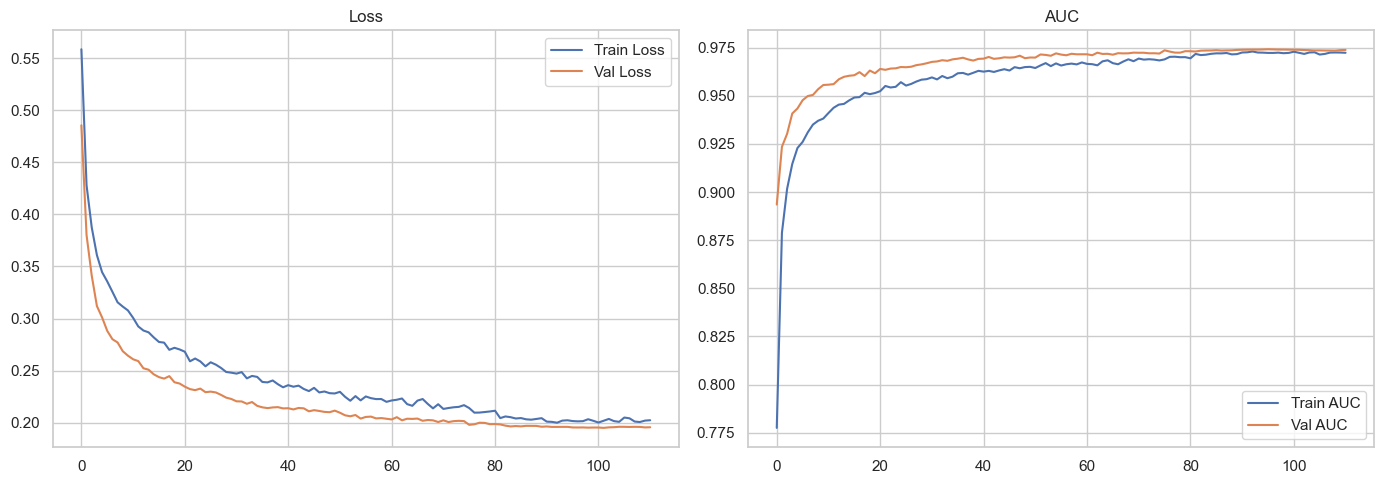

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.5 Evaluation on Test Set

215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step
860/860 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step
Neural Network:
  Train Acc: 0.9124
  Test Acc:  0.8989
  F1 Score:  0.8986
  AUC:       0.9755


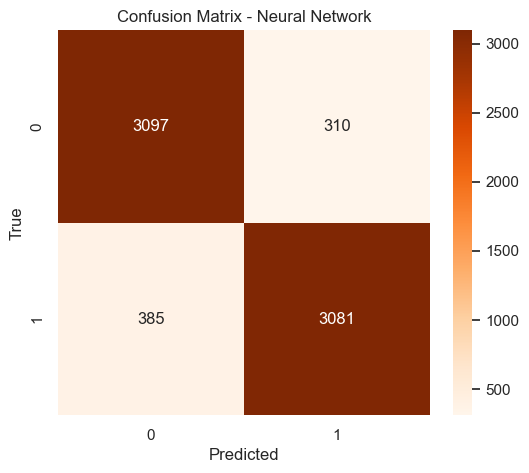

              precision    recall  f1-score   support

   Lost (-1)       0.89      0.91      0.90      3407
     Won (1)       0.91      0.89      0.90      3466

    accuracy                           0.90      6873
   macro avg       0.90      0.90      0.90      6873
weighted avg       0.90      0.90      0.90      6873



In [25]:
# Predictions
y_pred_proba_nn = nn_model.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

# Reconvertir en labels originaux : 0 -> -1, 1 -> 1
y_pred_nn_orig = np.where(y_pred_nn == 1, 1, -1)

# Metriques (memes que pour les modeles sklearn)
nn_test_acc = accuracy_score(y_test, y_pred_nn_orig)
nn_f1 = f1_score(y_test, y_pred_nn_orig)
nn_auc = roc_auc_score((y_test == 1).astype(int), y_pred_proba_nn)

# Train accuracy
y_pred_train_nn = (nn_model.predict(X_train_scaled).flatten() >= 0.5).astype(int)
y_pred_train_orig = np.where(y_pred_train_nn == 1, 1, -1)
nn_train_acc = accuracy_score(y_train, y_pred_train_orig)

print(f'Neural Network:')
print(f'  Train Acc: {nn_train_acc:.4f}')
print(f'  Test Acc:  {nn_test_acc:.4f}')
print(f'  F1 Score:  {nn_f1:.4f}')
print(f'  AUC:       {nn_auc:.4f}')

# Confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn_orig)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Neural Network')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Classification report
print(classification_report(y_test, y_pred_nn_orig, target_names=['Lost (-1)', 'Won (1)']))

## 9. RandomForest vs Neural Network — Final Comparison

In [26]:
comparison = pd.DataFrame([
    {
        'Model': 'RandomForest',
        'Train Acc': results['RandomForest']['train_acc'],
        'Test Acc': results['RandomForest']['test_acc'],
        'F1': results['RandomForest']['f1'],
        'AUC': results['RandomForest']['auc'],
    },
    {
        'Model': 'NeuralNetwork (Keras)',
        'Train Acc': nn_train_acc,
        'Test Acc': nn_test_acc,
        'F1': nn_f1,
        'AUC': nn_auc,
    },
])

print('\n=== RandomForest vs Neural Network ===')
print(comparison.to_string(index=False))

# Verdict
if nn_auc > results['RandomForest']['auc']:
    print(f'\n✓ WINNER: Neural Network (AUC +{nn_auc - results["RandomForest"]["auc"]:.4f})')
    final_best = 'NeuralNetwork'
else:
    print(f'\n✓ WINNER: RandomForest (AUC +{results["RandomForest"]["auc"] - nn_auc:.4f})')
    final_best = 'RandomForest'


=== RandomForest vs Neural Network ===
                Model  Train Acc  Test Acc       F1      AUC
         RandomForest   0.999964  0.938309 0.938887 0.986639
NeuralNetwork (Keras)   0.912447  0.898880 0.898644 0.975479

✓ WINNER: RandomForest (AUC +0.0112)


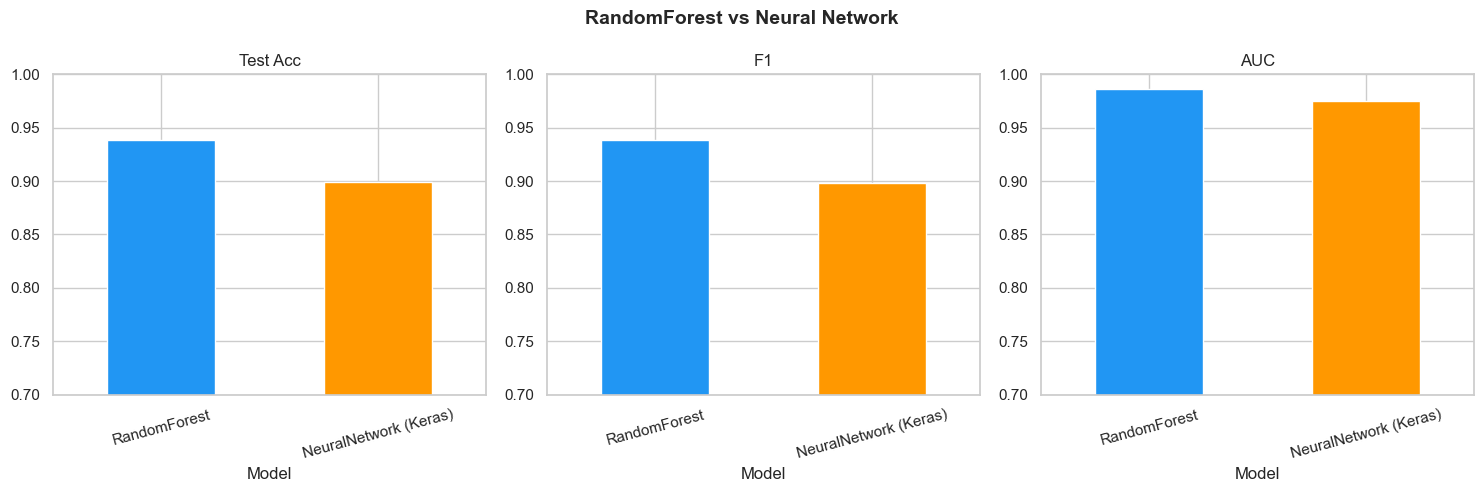

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Test Acc', 'F1', 'AUC']

for ax, metric in zip(axes, metrics):
    vals = comparison[['Model', metric]].set_index('Model')[metric]
    vals.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800'])
    ax.set_title(metric)
    ax.set_ylim(0.7, 1.0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.suptitle('RandomForest vs Neural Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Save Best Model

In [28]:
OUTPUT_PATH = Path('ml_selector.pkl')

# Save model
joblib.dump(best_model, OUTPUT_PATH)

print(f'✓ Model saved: {OUTPUT_PATH}')
print(f'  Type: {type(best_model).__name__}')
print(f'  Size: {OUTPUT_PATH.stat().st_size / 1024:.1f} KB')

# Verify
loaded = joblib.load(OUTPUT_PATH)
test_pred = loaded.predict(X_test[:5])
print(f'\n✓ Model loaded and working')
print(f'  Sample predictions: {test_pred}')

✓ Model saved: ml_selector.pkl
  Type: RandomForestClassifier
  Size: 33821.7 KB

✓ Model loaded and working
  Sample predictions: [ 1 -1 -1  1 -1]
